# Analysis 

Here we will take you through an analysis of different models, after having trained models with nested fold approach.

[IN PROGRESS]

In [1]:
## setup ##
from NM_TinyRNN.code.measures import analysis
from NM_TinyRNN.code.measures import mechanistic_variability as mech_var
from NM_TinyRNN.code.measures import reversal_metrics as revme
from NM_TinyRNN.code.measures import plotting_stats

from NM_TinyRNN.code.models import nested_jobs # this is the code used to train models!

import numpy as np
import pandas as pd
import torch #for testing a few things
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from importlib import reload

CODE_DIR = Path('.') ## OBS THIS MAY NEED TO BE ADJUSTED!
SAVE_PATH = CODE_DIR/'NM_TinyRNN/data/rnns'
DATA_PATH = Path('./NM_TinyRNN/data/AB_behaviour/')

%load_ext autoreload


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


We will perform analyses nd plotting primarily from pandas dataframes.
First we get an analysis_df, which contains a row for each model.
Each row has columns for
```python
'info_dict_path','trials_data_path','model_state_path'
``` 
 that we use to point to files and load data when running analyses.

Pandas dataframes also let us easily subset our data using .query(), so for this reason the analysis_df also has columns for 
```python
'model_type','hidden_size','nonlinearity','constraint'.
```

In [2]:
#construct analysis_df and have a look at a subset of data!
info_df = nested_jobs.get_job_info_df()
all_models_df = analysis.get_analysis_df(info_df, mode='all')

subset_df = all_models_df.query('subject_ID == "WS16" and model_id == "2_unit_monoGRU_relu_unipolar"')

subset_df

,Index,subject_ID,outer_loop_n,model_type,hidden_size,nonlinearity,input_encoding,constraint,nm_size,nm_dim,...,inner_loop_idx,info_path,model_state_path,training_losses_path,trials_data_path,eval_CE,best_val_CE,weight_seed,sparsity_lambda,energy_lambda
10125,1125,WS16,1,monoGRU,2,relu,unipolar,energy,1,1,...,0,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,0.634378,0.490165,10,0.00100,0.001
10126,1125,WS16,1,monoGRU,2,relu,unipolar,energy,1,1,...,1,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,0.624697,0.507323,10,0.00010,0.100
10127,1125,WS16,1,monoGRU,2,relu,unipolar,energy,1,1,...,2,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,0.645902,0.489674,10,0.00010,0.001
10128,1125,WS16,1,monoGRU,2,relu,unipolar,energy,1,1,...,3,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,0.645332,0.447114,10,0.00010,0.010
10129,1125,WS16,1,monoGRU,2,relu,unipolar,energy,1,1,...,4,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,0.648090,0.483856,1,0.00010,0.001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11425,1269,WS16,10,monoGRU,2,relu,unipolar,energy,1,1,...,4,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,0.482646,0.450732,10,0.00010,0.001
11426,1269,WS16,10,monoGRU,2,relu,unipolar,energy,1,1,...,5,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,0.481198,0.485852,10,0.00010,0.001
11427,1269,WS16,10,monoGRU,2,relu,unipolar,energy,1,1,...,6,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,0.484271,0.493905,7,0.00001,0.001
11428,1269,WS16,10,monoGRU,2,relu,unipolar,energy,1,1,...,7,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,NM_TinyRNN/data/rnns/nested_DA/WS16/monoGRU/en...,0.486852,0.485824,10,0.00010,0.001


### Performance

Here we want to summarise the held-out performance of different models, but also 

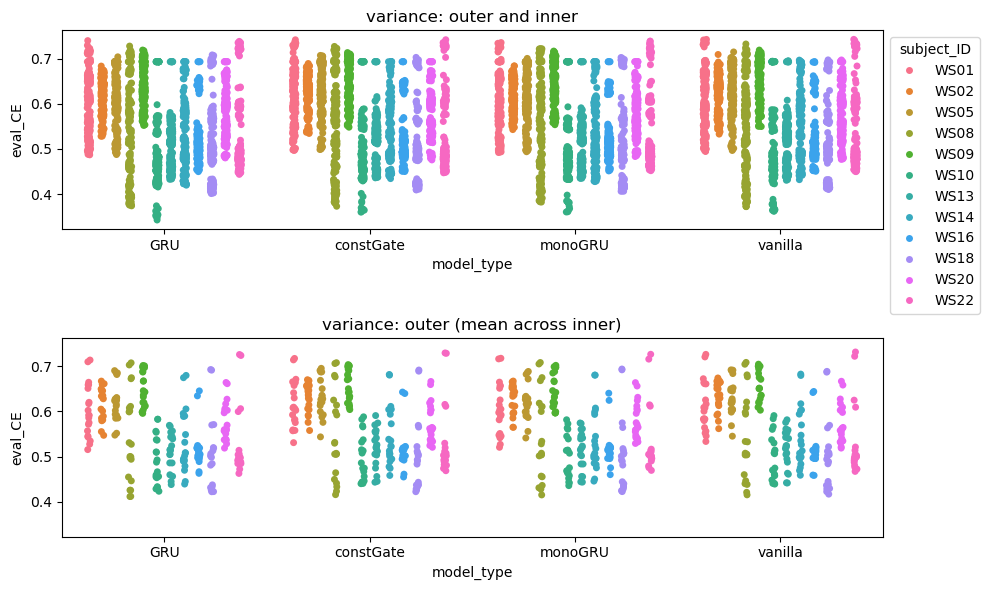

In [3]:
## SOME SUBJECTS HAVE MORE PREDICTABLE BEHAVIOUR THAN OTHERS

subject_df = all_models_df.groupby(['subject_ID','model_id','outer_loop_n',
                                    'model_type','hidden_size',
                                    'nonlinearity']).mean('eval_CE')
fig, ax = plt.subplots(2,1, figsize = (10,6), sharey=True)
ax[0].set_title('variance: outer and inner')

all_models_df = all_models_df.sort_values(by=['subject_ID','model_type'])
sns.stripplot(all_models_df.query('hidden_size==2'), x='model_type',y='eval_CE', 
              hue = 'subject_ID', legend = True, dodge=True,
              ax=ax[0], )
ax[1].set_title('variance: outer (mean across inner)')

subject_df = subject_df.sort_values(by=['subject_ID','model_type'])
sns.stripplot(subject_df.query('hidden_size==2'), x='model_type',y='eval_CE', 
              hue = 'subject_ID', legend = False, dodge=True,
              ax=ax[1])
sns.move_legend(ax[0], "upper left", bbox_to_anchor=(1, 1))

fig.tight_layout()


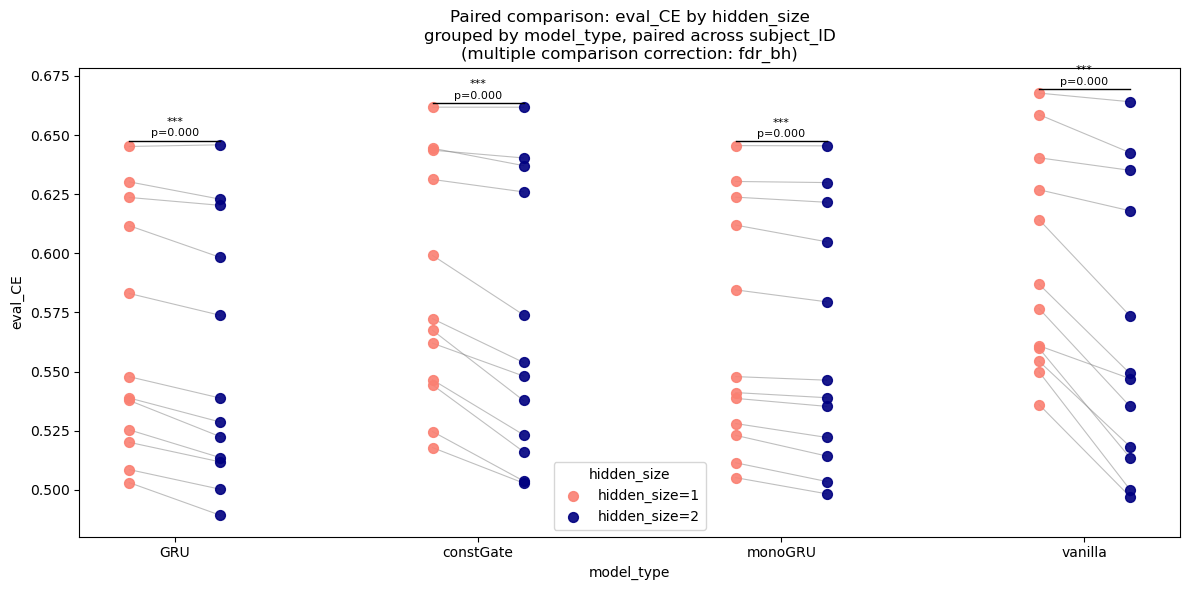

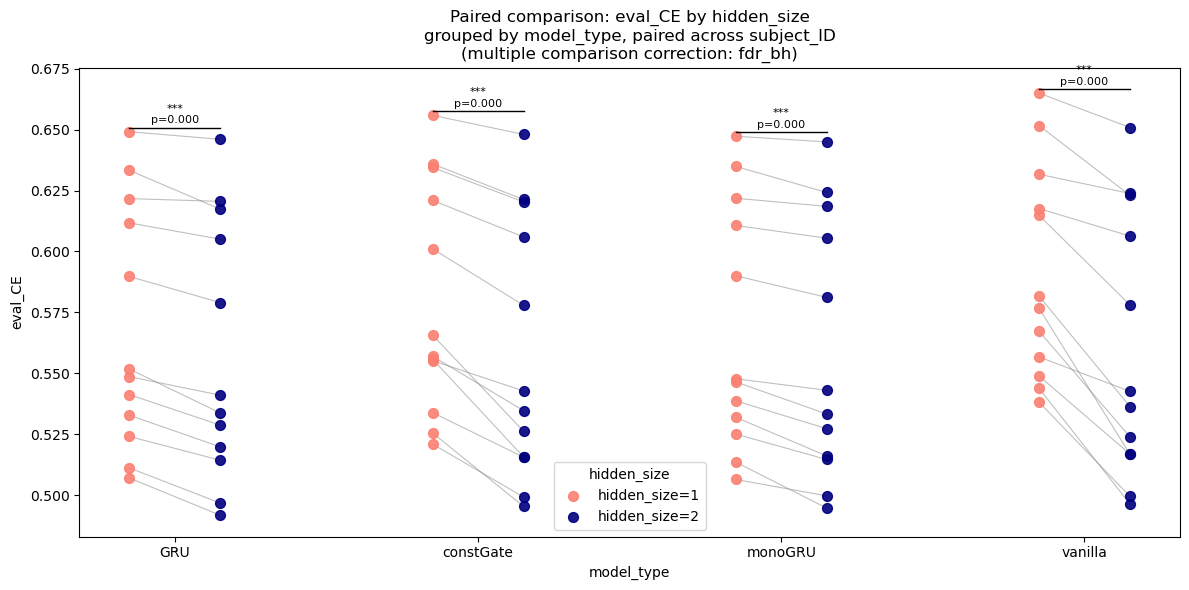

In [4]:
reload(plotting_stats)

tanh_models = all_models_df.query('nonlinearity=="tanh"')
plotting_stats.plot_paired_comparison(tanh_models,y='eval_CE',
                                      x='hidden_size',
                                      within_variable='model_type', 
                                      paired_across='subject_ID',
                                      mean_across='outer_loop_n',)

plt.show()


relu_models = all_models_df.query('nonlinearity=="relu"')
plotting_stats.plot_paired_comparison(relu_models,y='eval_CE',
                                      x='hidden_size',
                                      within_variable='model_type', 
                                      paired_across='subject_ID',
                                      mean_across='outer_loop_n',)

plt.show()



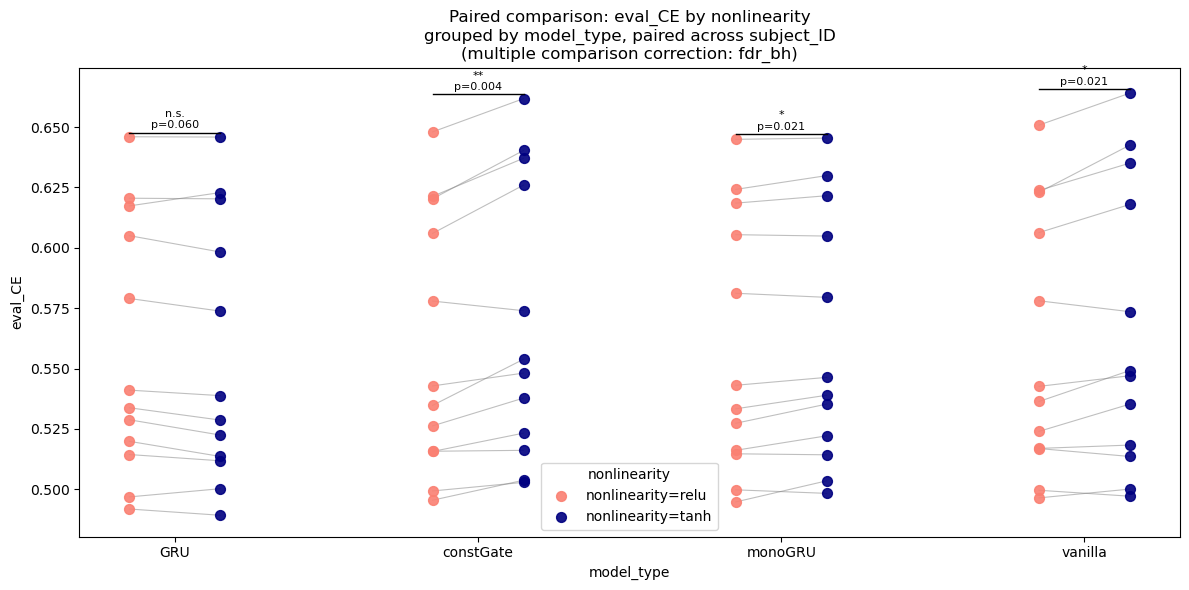

In [5]:
# is tanh performing better than RELU?


plotting_stats.plot_paired_comparison(all_models_df.query('hidden_size==2'),y='eval_CE',
                                      x='nonlinearity',
                                      within_variable='model_type', 
                                      paired_across='subject_ID',
                                      mean_across='outer_loop_n',)

plt.show()

N subjects with complete data: 12

Repeated measures ANOVA:
    Source  ddof1  ddof2         F    p_unc  p_GG_corr      ng2      eps  sphericity  W_spher  p_spher
model_type      3     33 11.953414 0.000019   0.001121 0.002725 0.514434       False 0.209712 0.009975

Post-hoc paired t-tests (fdr_bh corrected):
  constGate vs vanilla: t=1.36, mean_diff=0.0008, p_raw=0.2015, p_corr=0.2015 n.s.
  constGate vs monoGRU: t=2.36, mean_diff=0.0035, p_raw=0.0380, p_corr=0.0570 n.s.
  constGate vs GRU: t=4.86, mean_diff=0.0070, p_raw=0.0005, p_corr=0.0030 **
  vanilla vs monoGRU: t=1.73, mean_diff=0.0027, p_raw=0.1117, p_corr=0.1340 n.s.
  vanilla vs GRU: t=4.21, mean_diff=0.0062, p_raw=0.0015, p_corr=0.0033 **
  monoGRU vs GRU: t=4.14, mean_diff=0.0035, p_raw=0.0017, p_corr=0.0033 **


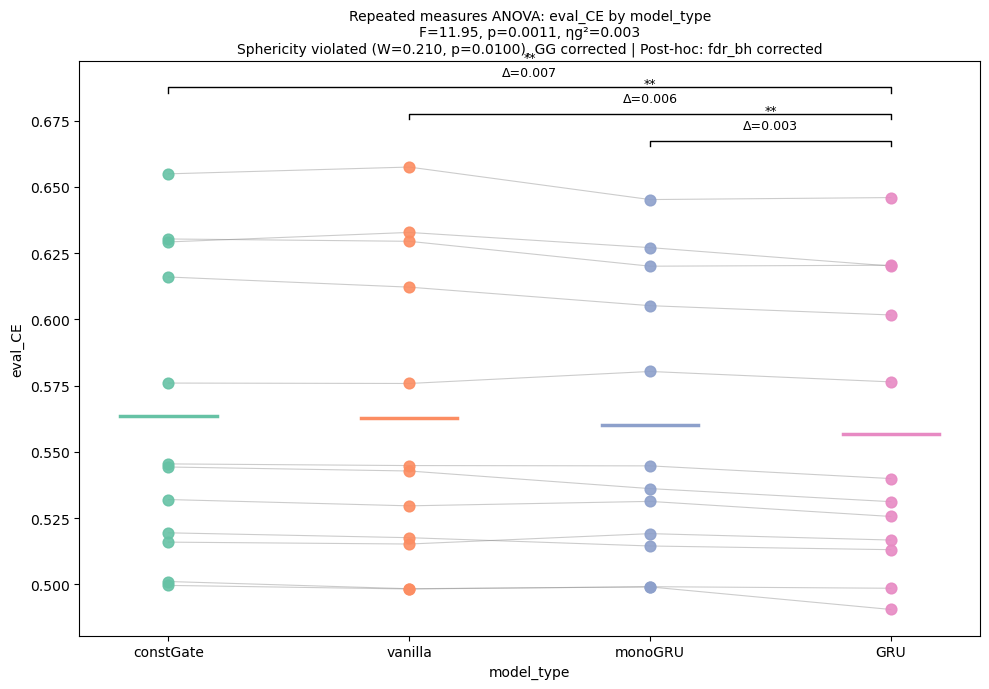

In [12]:
#Is there a difference for 2-unit relu models across architectures?
reload(plotting_stats)
plotting_stats.plot_repeated_measures_anova(subject_df.query('hidden_size==2'),
                                            y='eval_CE',
                                      x='model_type',
                                      paired_across='subject_ID',
                                      mean_across='outer_loop_n',)

plt.show()

### Reversals

testing/developing code to plot data for reversals

/ceph/behrens/wsilver/reversal/code/NM_TinyRNN/code/measures/reversal_metrics.py:45: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'RL' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[target_idx, 'reversal_type'] = rev_label


<Axes: xlabel='reversal_trial_index', ylabel='prob_B'>

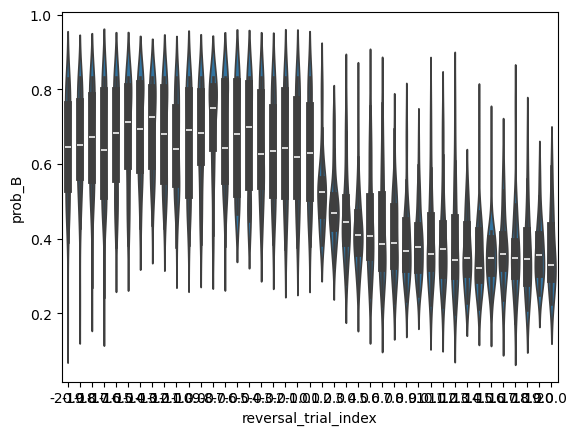

In [9]:

trials_data = analysis.load_data(all_models_df.iloc[2500].trials_data_path)
trials_data = revme.add_reversal_columns(trials_data)

fig, ax = plt.subplots()
sns.violinplot(trials_data.query('reversal_type=="RL"'),
                x='reversal_trial_index',
                y='prob_B',
                ax =ax)

### Mechanisms


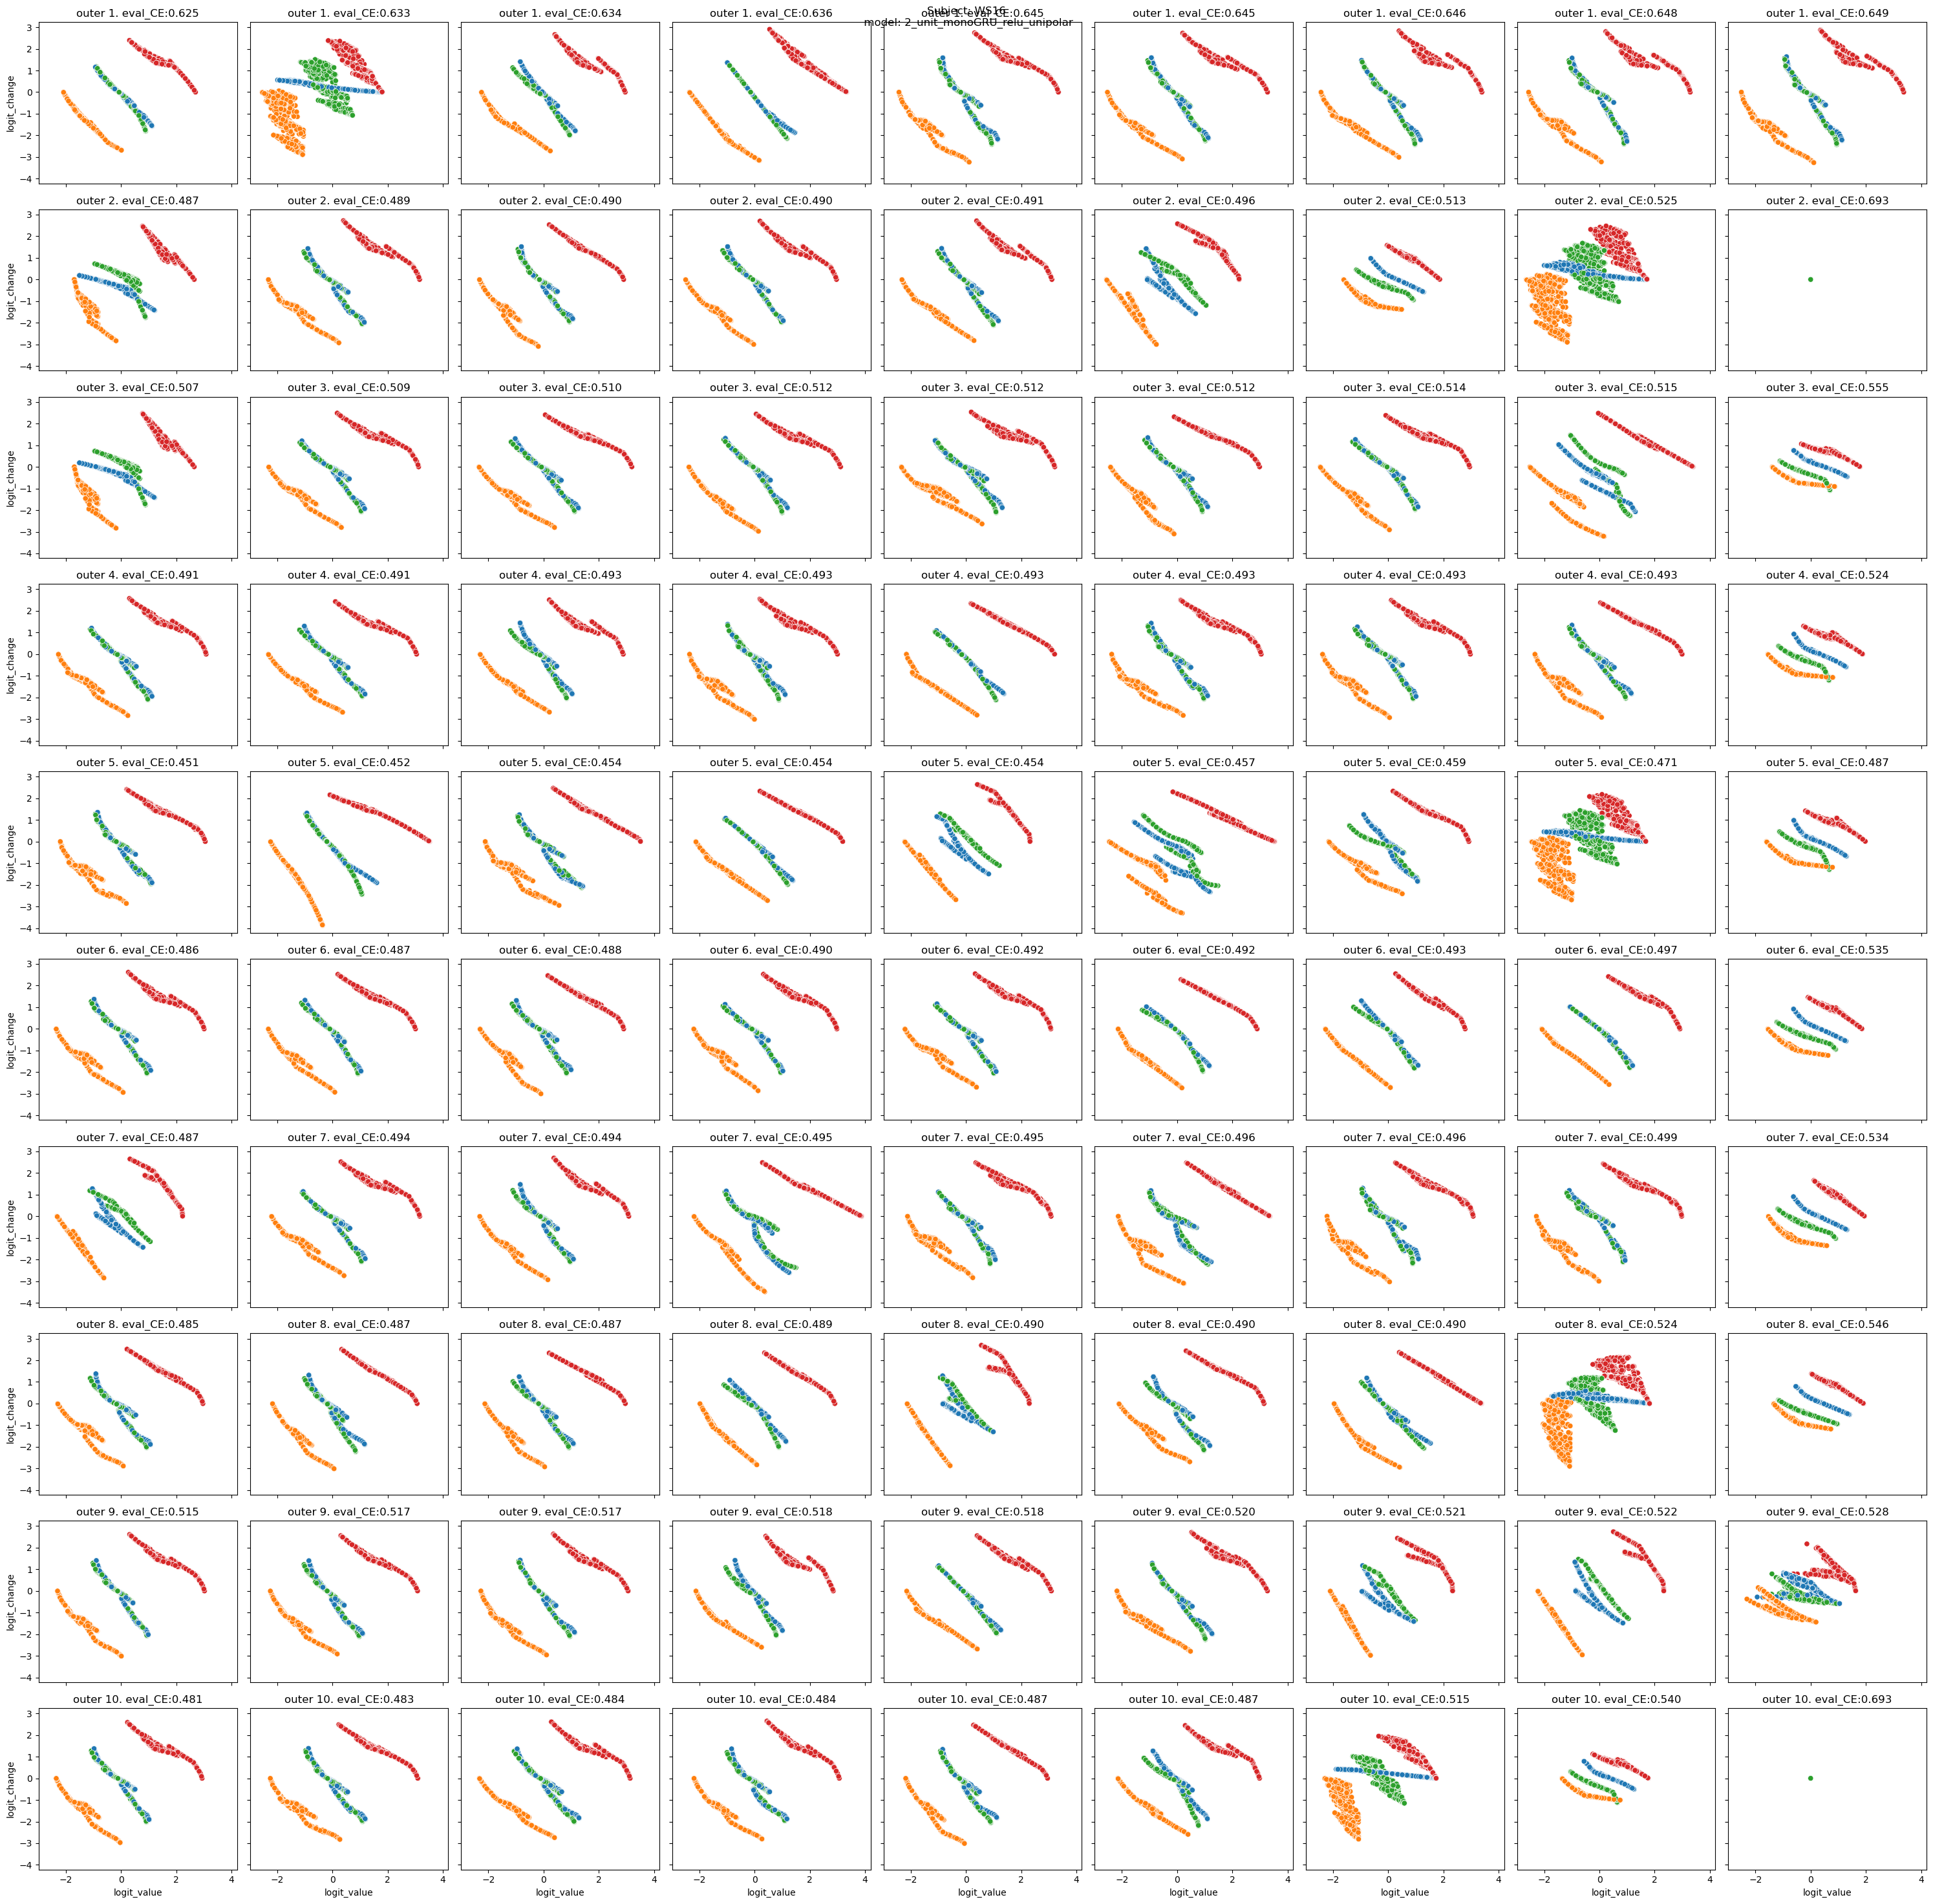

In [10]:
## Have a look at the mechanisms across folds !

subset_df = all_models_df.query('model_id=="2_unit_monoGRU_relu_unipolar" and subject_ID=="WS16"')

subset_df = subset_df.sort_values(by=['outer_loop_n','eval_CE'])

fig, ax = plt.subplots(10,9,figsize=(30,30), sharex=True, sharey=True)
axes = ax.flatten()
for i,each_row in enumerate(subset_df.itertuples()):
    
    trials_data = analysis.load_data(each_row.trials_data_path)
    sns.scatterplot(trials_data, x= 'logit_value',y='logit_change',
                    hue = 'trial_type',
                    legend = False, ax = axes[i])
    axes[i].set_title(f'outer {each_row.outer_loop_n}. eval_CE:{each_row.eval_CE:.3f}')
fig.suptitle(f'Subject: {each_row.subject_ID}\n model: {each_row.model_id}')
fig.tight_layout()

/nfs/nhome/live/cburns/miniconda3/envs/NM_TinyRNN/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/nfs/nhome/live/cburns/miniconda3/envs/NM_TinyRNN/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/nfs/nhome/live/cburns/miniconda3/envs/NM_TinyRNN/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/nfs/nhome/live/cburns/miniconda3/envs/NM_TinyRNN/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/nfs/nhome/live/cburns/miniconda3/envs/NM_TinyRNN/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/nfs/nhome/live/cburns/miniconda3/e

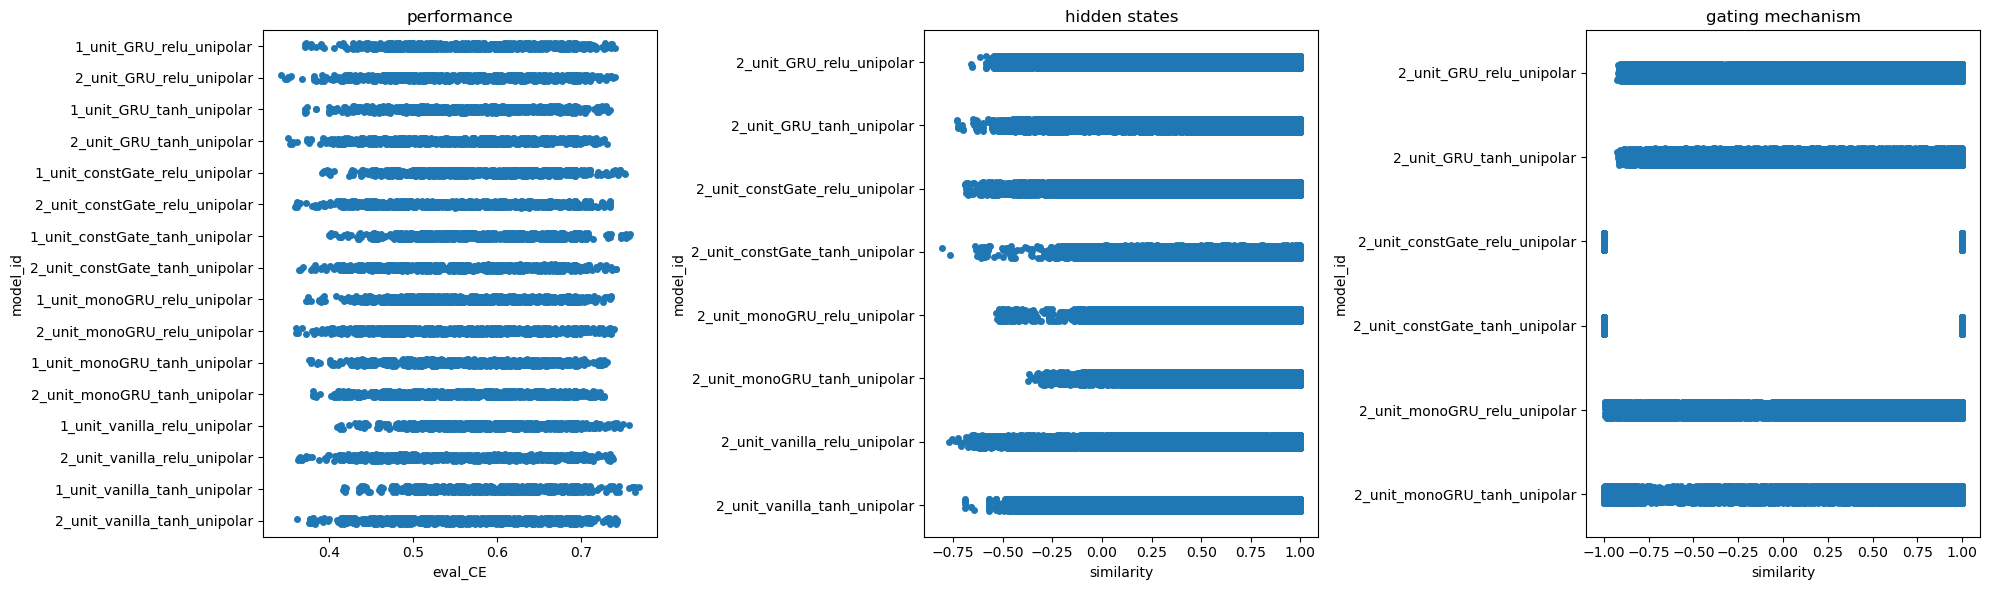

In [14]:
## what about mechanisms? are they more or less similar across models architectures?

reload(mech_var)
sim_df = mech_var.compute_similarities(all_models_df.query('hidden_size == 2'))
fig, ax = plt.subplots(1, 3, figsize=(20, 6))
sns.stripplot(data=all_models_df, y='model_id', x='eval_CE', ax=ax[0])
sns.stripplot(data=sim_df.query('component=="hidden"'), 
              y='model_id', x='similarity', ax=ax[1])
sns.stripplot(data=sim_df.query('component == "gate_update"'), 
              y='model_id', x='similarity', ax=ax[2])
ax[0].set(title='performance'); ax[1].set(title='hidden states'); ax[2].set(title='gating mechanism')
plt.tight_layout()
plt.show()

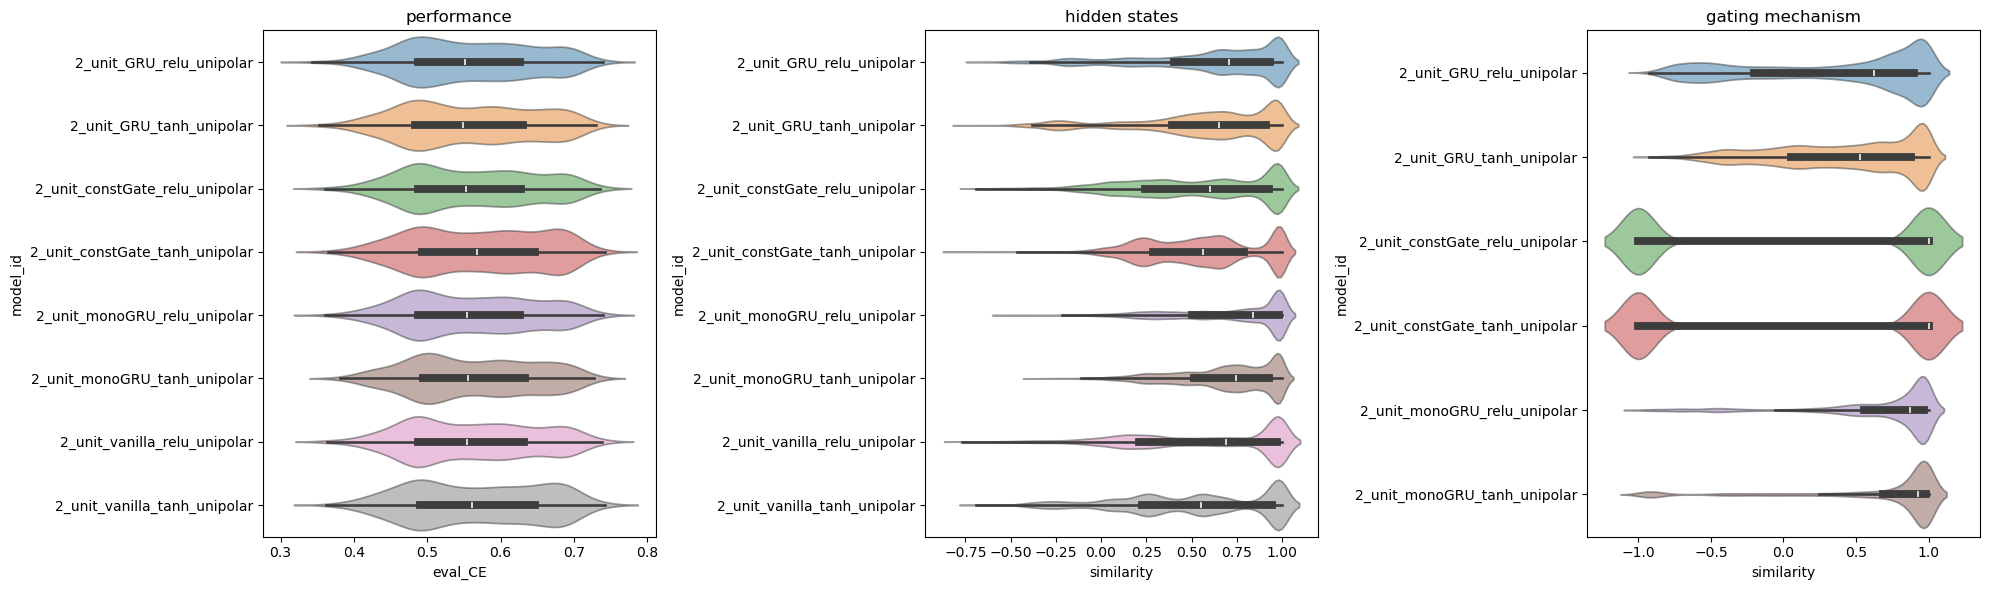

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))
sns.violinplot(data=all_models_df.query('hidden_size==2'), y='model_id', x='eval_CE', ax=ax[0],
               hue='model_id', alpha  = 0.5)
sns.violinplot(data=sim_df.query('component=="hidden"'), 
              y='model_id', x='similarity', ax=ax[1], 
              hue = 'model_id', alpha  = 0.5)
sns.violinplot(data=sim_df.query('component == "gate_update"'), 
              y='model_id', x='similarity', ax=ax[2], 
              hue='model_id', alpha  = 0.5)
ax[0].set(title='performance'); ax[1].set(title='hidden states'); ax[2].set(title='gating mechanism')
plt.tight_layout()
plt.show()